# Projection Methods for Data Set Analysis

Here we employ what we have implemented in Assignment 3 and 6, namely the following methods:
- PCA
- MDS
- LLE
- IsoMap

Note that this notebook requires normalized version of the data set, which is provided via another Jupyter notebook (see project path variables to set it correctly if needed)

In [16]:
%pip install scikit-learn==1.8.0
# 1.8 is needed for the recent function call arguments in MDS

Note: you may need to restart the kernel to use updated packages.


In [17]:
import pandas as pd
import numpy as np
import time
import math
import datetime
import seaborn as sns
import matplotlib.pylab as plt
import sklearn
import os
import scipy as sp

import dask.dataframe as dd # To work with large data sets
from sklearn.preprocessing import StandardScaler

In [18]:
# Some globals
PROJECT_PATH  = '.' #'/content/drive/MyDrive/CENG574_PROJECT'
PROJECT_RESULT_PATH = PROJECT_PATH + '/result/'
NORMALIZED_DATA_PATH = PROJECT_RESULT_PATH + 'normalized_pruned_yellow_tripdata_2015-01.parquet' # Our selected features (after normalization)

In [19]:
#from google.colab import drive
#drive.mount('/content/drive')

In [20]:

df =  pd.read_parquet(NORMALIZED_DATA_PATH)

n_samples, n_features = df.shape
print(f"[INFO] Loaded data set with total samples: {n_samples}")
print(f"[INFO] Number of features: {n_features}")

[INFO] Loaded data set with total samples: 12371288
[INFO] Number of features: 10


## Visualization tools

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Combining both of our shepard diagram functions
def plot_shepard_diagram_with_line(
    original_distances,
    projected_distances,
    title="Shepard Diagram"
):
    # Flatten distances
    original_flat = original_distances.flatten()
    projected_flat = projected_distances.flatten()

    # Debug info
    print(
        f"[DEBUG] Original distances: "
        f"min={original_flat.min():.4f}, "
        f"max={original_flat.max():.4f}, "
        f"std={original_flat.std():.4f}"
    )

    print(
        f"[DEBUG] Projected distances: "
        f"min={projected_flat.min():.4f}, "
        f"max={projected_flat.max():.4f}, "
        f"std={projected_flat.std():.4f}"
    )

    # Plot
    plt.figure(figsize=(8, 6))

    plt.scatter(
        original_flat,
        projected_flat,
        alpha=0.1,
        s=1
    )

    plt.axline(
        (0, 0),
        slope=1,
        color="red",
        linestyle="--",
        linewidth=2,
        label="Perfect Preservation"
    )

    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel(
        "Original Distances",
        fontsize=12
    )
    plt.ylabel(
        "Projected Distances",
        fontsize=12
    )

    plt.legend(loc="upper left")
    plt.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

In [22]:

import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

def plot_shepard_diagram(original_distances, projected_distances, title="Shepard Diagram"):

    original_flat = original_distances.flatten()
    projected_flat = projected_distances.flatten()

    print(f"[DEBUG] Original distances: min={original_flat.min():.4f}, max={original_flat.max():.4f}, std={original_flat.std():.4f}")
    print(f"[DEBUG] Projected distances: min={projected_flat.min():.4f}, max={projected_flat.max():.4f}, std={projected_flat.std():.4f}")

    plt.figure(figsize=(7, 7))
    plt.scatter(original_flat, projected_flat, alpha=0.5, s=10)

    plt.xlabel("Original Distances")
    plt.ylabel("Projected Distances")
    plt.title(title)
    plt.grid(True)

    plt.show()

def visualize_2d_projection(projected_data, labels=None, title='2D Projection'):

    df_plot = pd.DataFrame({
        "MDS1": projected_data[:, 0],
        "MDS2": projected_data[:, 1],
    })

    if labels is not None:

        df_plot["label"] = labels.astype(str)

        fig = px.scatter(
            df_plot,
            x="MDS1",
            y="MDS2",
            #hover_name="name",
            color="label",
        )

    else:

        fig = px.scatter(
            df_plot,
            x="MDS1",
            y="MDS2",
            #hover_name="name"
        )

    fig.update_layout(
        title=title,
        width=900,
        height=700
    )

    fig.show()

def plot_mds_stress_vs_iterations(iterations, stress_values):

    plt.figure()

    plt.plot(iterations, stress_values, marker='o')

    plt.xlabel("Maximum Iterations")
    plt.ylabel("Stress (Error)")
    plt.title("MDS Stress vs. Iterations")

    plt.xticks(iterations)
    plt.grid(True)

    plt.show()

In [23]:
# Visualising the clusters on a map
# DISCLAIMER: Adapted from
# https://www.kaggle.com/code/elemento/nyc-yellowtriptaxi/notebook
def plot_long_lat(frame, cluster_vals='blue', max_samples=100000):
    city_long_border = (-74.03, -73.75)
    city_lat_border = (40.63, 40.85)
    fig, ax = plt.subplots(ncols=1, nrows=1, figsize = (12, 10))

    long_vals = frame.pickup_longitude.values[:max_samples]
    lat_vals = frame.pickup_latitude.values[:max_samples]
    print(f"[DEBUG] Long_vals shape: {long_vals.shape}, lat_vals shape: {lat_vals.shape}")
    ax.scatter(long_vals, lat_vals, c=cluster_vals,
              s=10, lw=0, alpha=0.8)
    #ax.set_xlim(city_long_border)
    #ax.set_ylim(city_lat_border)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.show()


# Principal Component Analysis (PCA)

In [24]:

# Use normalized data before PCA
X_normalized = df

pca = sklearn.decomposition.PCA()
tfdf= pca.fit_transform(X_normalized) # transformed data

eig_vals = evalf = pca.explained_variance_ # eigenvalues
eig_vecs = evecf = pca.components_ # eigenvectors
explained_var = vrf = pca.explained_variance_ratio_ # variance_ratio

print("Eigenvalues")
print(np.round(eig_vals, 4))

print("\nExplained Variance Ratio")
print(np.round(explained_var, 4))

Eigenvalues
[3.6311 1.5176 1.0363 0.998  0.8244 0.7155 0.5513 0.5307 0.1588 0.0361]

Explained Variance Ratio
[0.3631 0.1518 0.1036 0.0998 0.0824 0.0716 0.0551 0.0531 0.0159 0.0036]


## Scree Plot

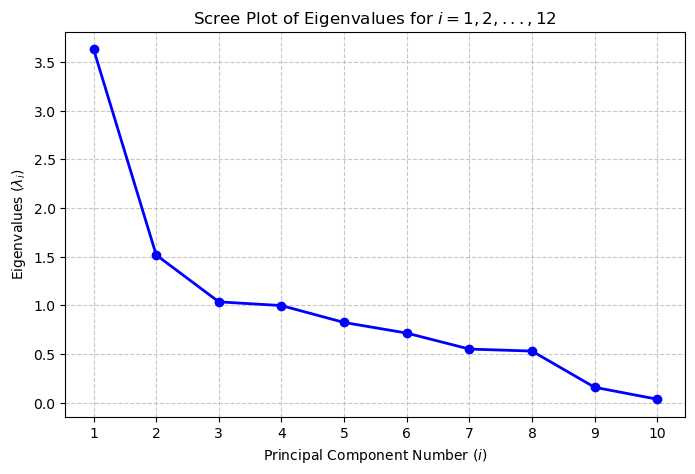

In [25]:
import matplotlib.pyplot as plt

components = np.arange(1, n_features + 1)

plt.figure(figsize=(8, 5))
plt.plot(components, eig_vals, marker='o', linestyle='-', color='b', linewidth=2)
plt.title('Scree Plot of Eigenvalues for $i=1,2,...,12$')
plt.xlabel('Principal Component Number ($i$)')
plt.ylabel('Eigenvalues ($\\lambda_i$)')
plt.xticks(components)
plt.grid(True, linestyle='--', alpha=0.7)

# export scree graph
plt.savefig(PROJECT_RESULT_PATH + 'scree_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### Proportion of variance

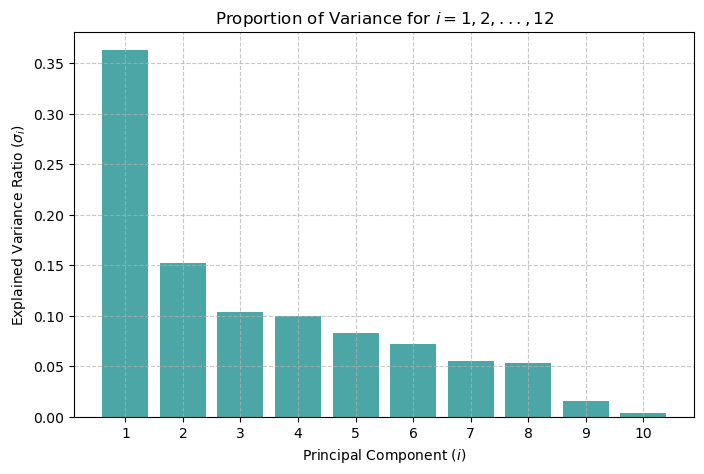

In [26]:
################# proportion of variance
#### vrf: var_ratio array

plt.figure(figsize=(8, 5))
plt.bar(components, vrf, color='teal', alpha=0.7)
plt.title('Proportion of Variance for $i=1,2,...,12$')
plt.xlabel('Principal Component ($i$)')
plt.ylabel('Explained Variance Ratio ($\\sigma_i$)')
plt.xticks(components)
plt.grid(True, linestyle='--', alpha=0.7)

# export
plt.savefig(PROJECT_RESULT_PATH + 'var_plot.png', dpi=300, bbox_inches='tight')
plt.show()

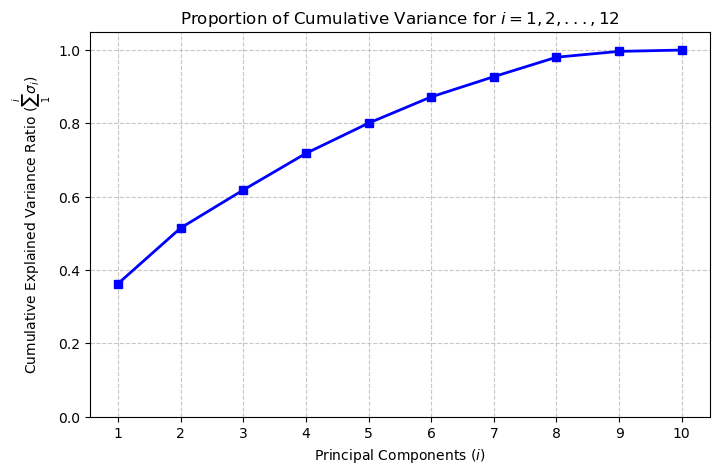

In [27]:
####################### cumulative variance plot
#### vrf: var_ratio array

cvrf = np.cumsum(vrf)
plt.figure(figsize=(8, 5))
plt.plot(components, cvrf, marker='s', color='b', linewidth=2)
plt.title('Proportion of Cumulative Variance for $i=1,2,...,12$')
plt.xlabel('Principal Components ($i$)')
plt.ylabel('Cumulative Explained Variance Ratio ($\\sum_1^i {\\sigma_i}$)')
plt.xticks(components)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim([0,1.05])

# export
plt.savefig(PROJECT_RESULT_PATH + 'cvar_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## Directions of the PCs


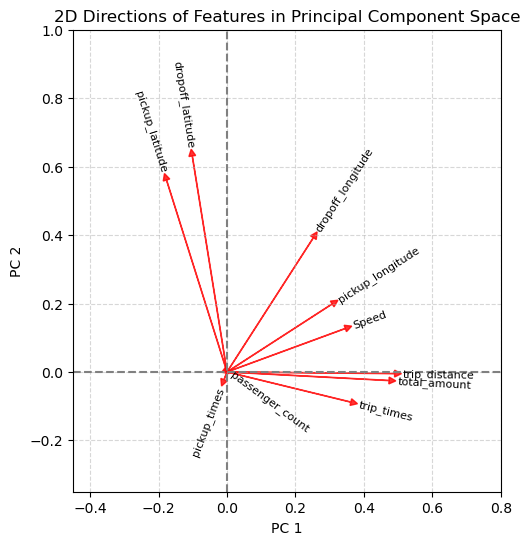

In [28]:
############################ plotting the directions of the principal components: 2 PC
#### evecf: evec array
#### evalf: eval array
#### vrf: var_ratio array

v_names = df.columns

PC1 = evecf[0]
PC2 = evecf[1]

plt.figure(figsize=(8,6))
offset = 0.005

for i in range(n_features):
    plt.arrow(0, 0, PC1[i], PC2[i],
              color='red', alpha=0.8, head_width=0.02, head_length=0.02,
              length_includes_head=True)
    ## some trigonometry
    rad = np.arctan2(PC2[i], PC1[i])
    deg = np.degrees(rad)

    offset_x = offset * np.cos(rad)
    offset_y = offset * np.sin(rad)

    if(PC1[i]<0):
      plt.text(PC1[i]+offset_x, PC2[i]+ offset_y, v_names[i],
             color='black', ha='right', va='center', rotation=deg+180, rotation_mode='anchor', fontsize=8)
    else:
      plt.text(PC1[i]+offset_x, PC2[i]+ offset_y, v_names[i],
             color='black', ha='left', va='center', rotation=deg, rotation_mode='anchor', fontsize=8)

# Set up the graph formatting
plt.gca().set_aspect('equal') # important for correct angled labels

plt.xlim(-0.45, 0.8)
plt.ylim(-0.35, 1.0)
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')

plt.xlabel(f'PC 1')
plt.ylabel(f'PC 2')
plt.title('2D Directions of Features in Principal Component Space')
plt.grid(True, linestyle='--', alpha=0.5)

# Export the plot
plt.savefig(PROJECT_RESULT_PATH + 'directions_plot_2d.png', dpi=300, bbox_inches='tight')
plt.show()

## Transformed data onto to the new coordinate system*

In [29]:
######################### PROJECTION: 2D
# tfdf : transformed data final
#### evecf: evec array
#### evalf: eval array
#### vrf: var_ratio array
SKIP_2D_PLOT = True

if not SKIP_2D_PLOT:
  plt.figure(figsize=(10, 8))
  plt.scatter(tfdf[:, 0], tfdf[:, 1],
              alpha=0.6, c='teal', edgecolors='k', s=50)

  plt.title('Data Transformed onto the First Two Principal Components', fontsize=14)
  plt.xlabel(f'Principal Component 1', fontsize=12)
  plt.ylabel(f'Principal Component 2', fontsize=12)

  plt.axhline(0, color='black', linewidth=1, linestyle='--')
  plt.axvline(0, color='black', linewidth=1, linestyle='--')
  plt.grid(True, linestyle=':', alpha=0.6)

  # export
  plt.savefig(PROJECT_RESULT_PATH + 'data_2d_transformed.png', dpi=300, bbox_inches='tight')
  plt.show()

In [30]:
################### projection 3d
# tfdf : transformed data final
#### evecf: evec array
#### evalf: eval array
#### vrf: var_ratio array

SKIP_3D_PLOT = True

if not SKIP_3D_PLOT:
  fig = plt.figure(figsize=(12, 9))
  ax = fig.add_subplot(111, projection='3d')
  scatter = ax.scatter(tfdf[:, 0], tfdf[:, 1], tfdf[:, 2],
                      alpha=0.6, c='coral', edgecolors='k', s=50)

  ax.set_title('Data Transformed onto the First Three Principal Components', y = 0.9)

  ax.set_xlabel('Principal Component 1', labelpad=3)
  ax.set_ylabel('Principal Component 2', labelpad=3)
  ax.set_zlabel('Principal Component 3', labelpad=-1)

  xlim = ax.get_xlim()
  ylim = ax.get_ylim()
  zlim = ax.get_zlim()

  ax.plot(xlim, [0, 0], [0, 0], color='black', linestyle='--', linewidth=1)
  ax.plot([0, 0], ylim, [0, 0], color='black', linestyle='--', linewidth=1)
  ax.plot([0, 0], [0, 0], zlim, color='black', linestyle='--', linewidth=1)

  ### elev 10 20 30
  ### 45, 135, 225, or 315 azim
  ax.view_init(elev=10, azim=315)
  ax.set_box_aspect(None, zoom=0.90)
  # export
  plt.savefig(PROJECT_RESULT_PATH + 'data_3d_transformed', dpi=300, bbox_inches='tight')
  plt.show()

## Random Sampling for nonlinear projections

In [31]:
n_samples = len(df)
n_subsamples = 2000

random_idxs = np.random.choice(
    n_samples,
    size=n_subsamples,
    replace=False
)

X = df_subset = df.iloc[random_idxs]
print("Working with dataset of shape: ", df_subset.shape)

Working with dataset of shape:  (2000, 10)


[DEBUG] Long_vals shape: (2000,), lat_vals shape: (2000,)


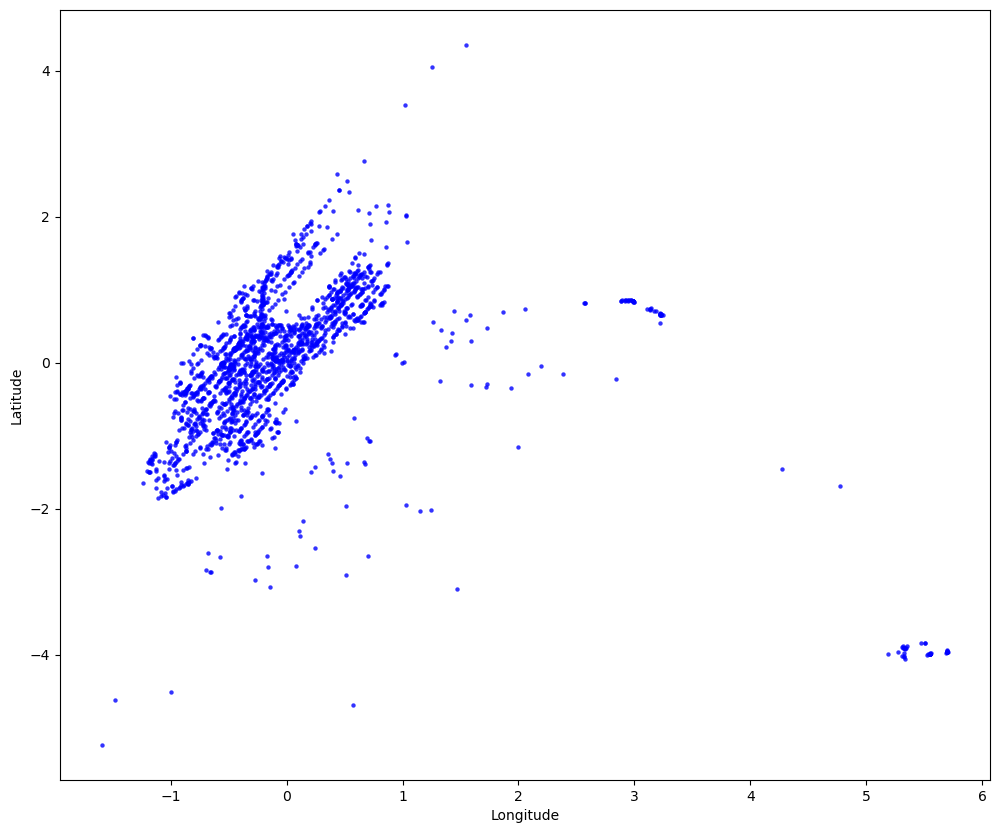

In [32]:
# To visualize our sampling
plot_long_lat(frame=X)

# Multi-Dimensional Scaling

In [33]:
# Cosine similarity
#similarity = sklearn.metrics.pairwise.cosine_similarity(X=X, Y=None, dense_output=False) # Sparse matrix
#distances = 1 - similarity

# Euclidean Distances --> Seem to work better in our case
distances = sklearn.metrics.pairwise.euclidean_distances(X=X, Y=None)
print(f"[INFO] Computed similarity matrix of shape {distances.shape}")

[INFO] Computed similarity matrix of shape (2000, 2000)


In [34]:

# n_mds_trials: How many times to run random initialization config
# n_iters: number of sample points to check error

n_mds_trials=1

print(f"[INFO] There will be {n_mds_trials} trials for MDS random initializations.")

min_error = np.inf
best_config_mds = None
best_embedding_mds = None

# Try different random initial configurations
for i in range(n_mds_trials):

    random_state =  np.random.randint(low=1, high=100) # For reproducibility in the upcoming tasks
    print(f"[DEBUG] Chosen random state: {random_state}")

    #Based on: https://scikit-learn.org/stable/auto_examples/manifold/plot_mds.html
    mds = sklearn.manifold.MDS(
          n_components=2,
          max_iter=300,
          eps=1e-9,
          n_init=1,
          random_state=random_state,
          metric="precomputed",
          metric_mds=True, # If True, perform metric MDS; otherwise, perform nonmetric MDS.
          n_jobs=1,
          init="random", # init{‘random’, ‘classical_mds’} -> Note: if set to classical mds, n_inits is set to 1
          verbose=1
      )

    mds_start = time.time()
    fit = mds.fit(distances)
    X_mds, error = fit.embedding_, fit.stress_ # Stress value is mentioned in Week 4 Slides, p.19
    mds_end = time.time()
    print(f"[{i+1}/{n_mds_trials}] Performed MDS {X_mds.shape}, took {mds_end - mds_start:.4f} seconds. Final error: {error:.4f}")

    if error < min_error:
          min_error = error
          best_config_mds = mds
          best_embedding_mds = mds.embedding_
          print(f"\t[DEBUG] Updated minimum error to {min_error:.4f} (random state = {best_config_mds.random_state})")

[INFO] There will be 1 trials for MDS random initializations.
[DEBUG] Chosen random state: 44
[1/1] Performed MDS (2000, 2), took 19.4450 seconds. Final error: 2058340.6265
	[DEBUG] Updated minimum error to 2058340.6265 (random state = 44)


In [35]:

# Choose the one that gives minimum error ------------------------------------------------------------------------------
# and we compute best configuration MDS for different iterations for the next task
# note that here we set max_iters to set iterations but convergence might be reached
# prior to max_iter.

n_iters = 0 # For error-iter graph

print("[INFO] Using the minimum error fit...")
print(f"[DEBUG] Best configuration MDS has random state = {best_config_mds.random_state} and params:\n {best_config_mds.get_params()}")

start_iters = 10
stop_iters = 300
max_iterations = np.linspace(start_iters, stop_iters, n_iters, dtype=int)

error_iterations = []
print(f"[DEBUG]: Run MDS for the max iterations: {max_iterations}")
for n, it in enumerate(max_iterations):

      best_config_mds.max_iter = it # Q: Does it re-compute or continue from the last iter? A: It recomputes
      best_config_mds.set_params()
      fit_iter = best_config_mds.fit(distances)
      error_iter = fit_iter.stress_
      print(f"[{n+1}/{len(max_iterations)}] Found error in this iteration: {error_iter:.2f} (max_iter = {best_config_mds.max_iter})")
      error_iterations.append(error_iter)



[INFO] Using the minimum error fit...
[DEBUG] Best configuration MDS has random state = 44 and params:
 {'dissimilarity': 'deprecated', 'eps': 1e-09, 'init': 'random', 'max_iter': 300, 'metric': 'precomputed', 'metric_mds': True, 'metric_params': None, 'n_components': 2, 'n_init': 1, 'n_jobs': 1, 'normalized_stress': 'auto', 'random_state': 44, 'verbose': 1}
[DEBUG]: Run MDS for the max iterations: []


### Visualize MDS

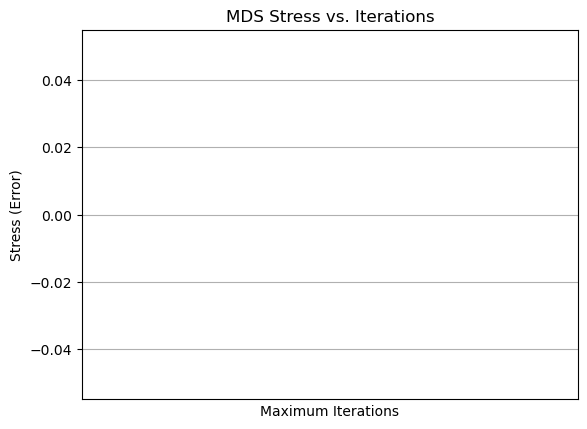

In [36]:
 # Plot the scree graph (error vs. iterations) for the chosen configuration
plot_mds_stress_vs_iterations(
        iterations=max_iterations,
        stress_values=error_iterations
)

# Plot the data by the chosen projection
#ground_truth = load_dataset.get_ground_truth_labels(dataframe=dataframe)
visualize_2d_projection(
        projected_data=X_mds,
        #mesh_names=dataframe["mesh_name"].values,
        #labels= ground_truth, # This is to colorize the samples based on their GT class
        title="2D Projection of Metric MDS"
)


# Other Nonlinear Projections
* Locally Linear Embedding (LLE)
* IsoMap

In [37]:
# LLE ------------------------------------------------------------------------------------------------------------
embedding_lle = sklearn.manifold.LocallyLinearEmbedding(
                                                    n_components=2,
                                                    n_neighbors=30,
                                                    eigen_solver='dense', # 'arpack' might raise ValueError
                                                    )

In [38]:
# IsoMap --------------------------------------------------------------------------------------------------------
embedding_iso = sklearn.manifold.Isomap(
                                    n_components=2,
                                    n_neighbors=40, # NOTE: Increased neighbour count to silence the sparsity conversion warning
                                    )

In [39]:
embeddings = [(embedding_lle, "LLE"), (embedding_iso, "IsoMap")] # (embedding, "name")

In [40]:
fitted_embeddings = []
for embedding, name in embeddings:
  task3_start = time.time()
  embed_fit = embedding.fit(X)
  task3_end = time.time()
  X_transformed = embed_fit.embedding_
  print(f"[DEBUG] Performed {name}, took {task3_end - task3_start:.4f} seconds.")

  fitted_embeddings.append((X_transformed, name))

  #ground_truth = load_dataset.get_ground_truth_labels(dataframe=dataframe)
  visualize_2d_projection(
          projected_data=X_transformed,
          #labels= ground_truth, # This is to colorize the samples based on their GT class
          title=f"2D Projection of {name}"
    )

[DEBUG] Performed LLE, took 0.3321 seconds.


[DEBUG] Performed IsoMap, took 2.3218 seconds.


# Shepard Diagrams

[DEBUG] Original distances: min=0.0000, max=16.4018, std=2.2303
[DEBUG] Projected distances: min=0.0000, max=21.7727, std=2.5408


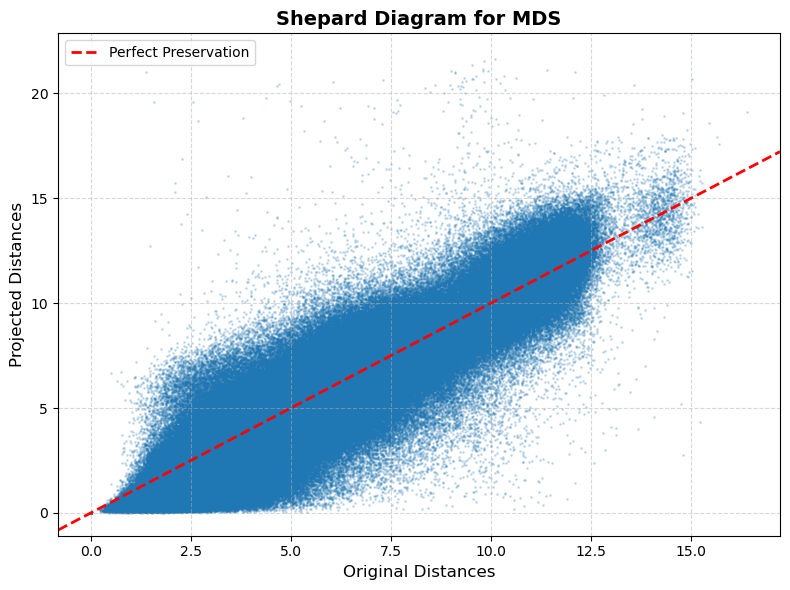

[DEBUG] Original distances: min=0.0000, max=16.4018, std=2.2303
[DEBUG] Projected distances: min=0.0000, max=0.2124, std=0.0307


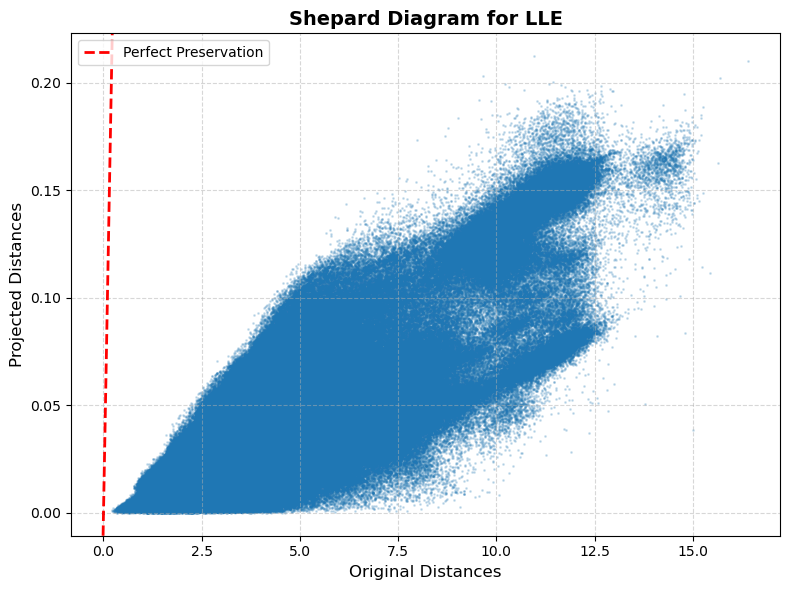

[DEBUG] Original distances: min=0.0000, max=16.4018, std=2.2303
[DEBUG] Projected distances: min=0.0000, max=17.5519, std=2.6915


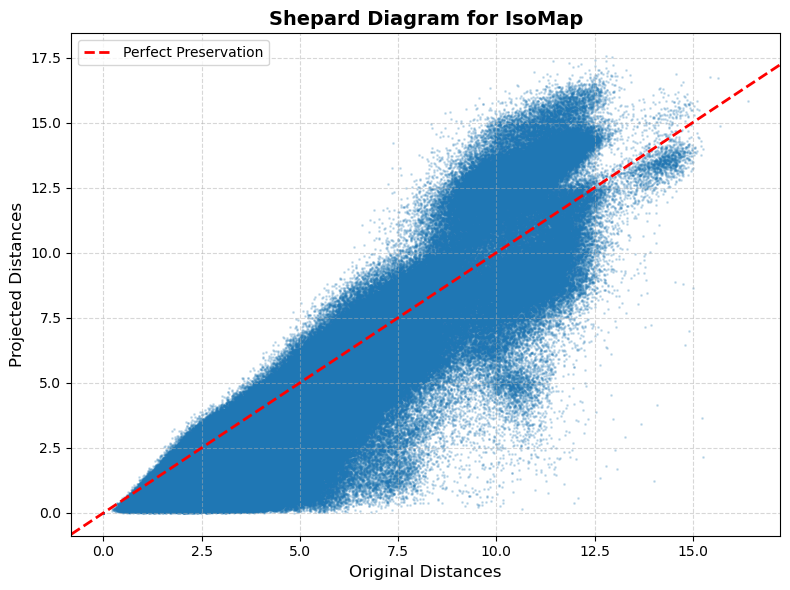

In [41]:
projections = [(best_embedding_mds, "MDS")]
for fit, name in fitted_embeddings:
  projections.append((fit, name)) # LLE, Isomap are appended


for projection, name in projections:
        if projection is not None:
            projected_distances = sklearn.metrics.pairwise.pairwise_distances(projection)
            plot_shepard_diagram_with_line(
                    original_distances=distances,
                    projected_distances=projected_distances,
                    title=f"Shepard Diagram for {name}"
            )
